# Notebook 2: Exploratory Data Analysis (EDA)

---

## Objective

This notebook performs exploratory data analysis to understand the overall characteristics of the business and identify initial patterns in sales and customer behavior.

---

## Business Context

After cleaning the data, we need to answer basic business questions:

- Which countries generate the most revenue?
- What are our best-selling products?
- When do customers buy (time of day, day of week)?
- Who are our top customers?
- What is the typical transaction value?

These insights help the business understand its current position and identify areas for improvement before diving into deeper customer segmentation.

---

## What This Notebook Covers

- Geographic revenue distribution (top countries)
- Product performance analysis (top products by revenue)
- Monthly revenue trends and seasonality
- Hourly transaction patterns (best times to sell)
- Weekly transaction patterns (best days to sell)
- Customer concentration (top customers by spending)
- Transaction value distribution
- Customer purchase frequency analysis
- Order value distribution

---

## Key Business Questions Answered

| Question | Why It Matters |
|----------|----------------|
| Where should we focus geographic expansion? | International growth opportunities |
| Which products drive the most revenue? | Inventory and marketing focus |
| When should we schedule marketing campaigns? | Maximize conversion rates |
| How concentrated is our customer base? | Risk assessment |
| What is our typical customer purchase behavior? | Customer understanding |

---

## Expected Output

- Visualizations saved to `../outputs/figures/`
- Summary statistics saved to `../outputs/tables/`
- Key business metrics identified for reporting

---

## Begin Analysis

Run the cells below to perform exploratory data analysis.

### Import Libraries and Load Data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load cleaned data
df_clean = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])

print("Data loaded successfully!")
print(f"Shape: {df_clean.shape}")

Data loaded successfully!
Shape: (396337, 15)


### Dataset Overview Print

In [26]:
print("Dataset Overview")
print("=" * 50)
print(f"Total transactions: {len(df_clean):,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Unique products: {df_clean['StockCode'].nunique():,}")
print(f"Unique countries: {df_clean['Country'].nunique()}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: ${df_clean['TotalPrice'].sum():,.2f}")

Dataset Overview
Total transactions: 396,337
Unique customers: 4,334
Unique products: 3,659
Unique countries: 37
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue: $8,761,066.65


### Top 10 Countries by Revenue

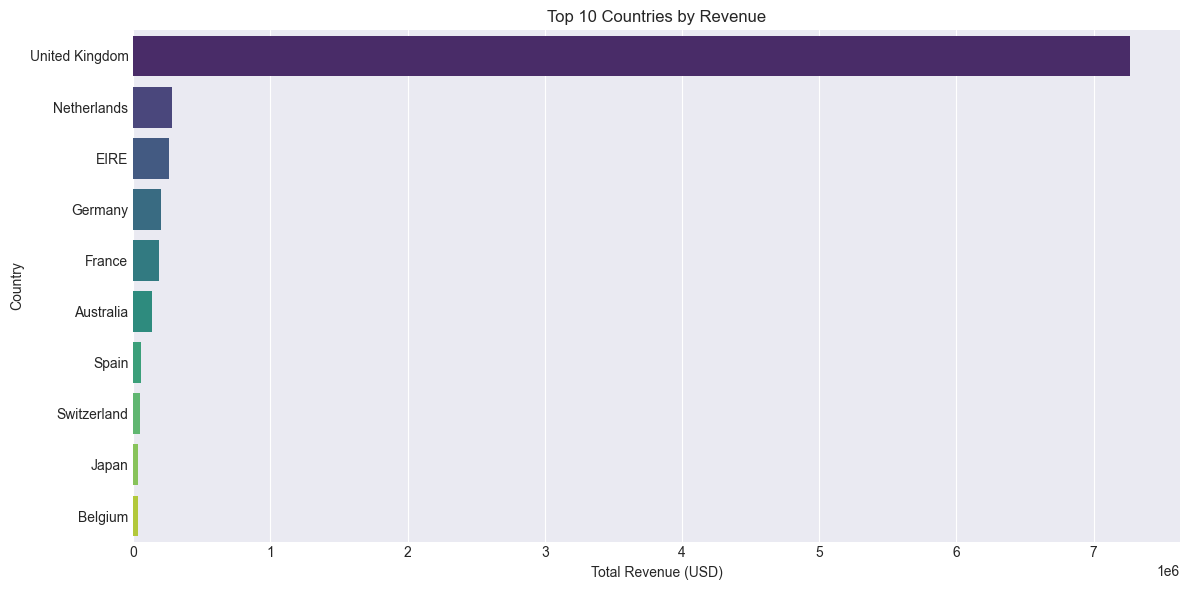

In [27]:
# Calculate top countries by revenue
country_revenue = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, hue=country_revenue.index, legend=False, palette='viridis')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.savefig('../outputs/figures/top_countries_revenue.png', dpi=100)
plt.show()

### UK vs International Revenue Breakdown

In [28]:
# Calculate revenue breakdown
uk_revenue = country_revenue.get('United Kingdom', 0)
international_revenue = df_clean[df_clean['Country'] != 'United Kingdom']['TotalPrice'].sum()
total_revenue = df_clean['TotalPrice'].sum()

print("Revenue Breakdown:")
print("-" * 30)
print(f"United Kingdom: ${uk_revenue:,.2f} ({uk_revenue/total_revenue*100:.1f}%)")
print(f"International: ${international_revenue:,.2f} ({international_revenue/total_revenue*100:.1f}%)")
print(f"Other top countries:")
for i, (country, revenue) in enumerate(country_revenue.iloc[1:6].items(), 2):
    print(f"  {i}. {country}: ${revenue:,.2f}")

Revenue Breakdown:
------------------------------
United Kingdom: $7,265,862.23 (82.9%)
International: $1,495,204.42 (17.1%)
Other top countries:
  2. Netherlands: $283,889.34
  3. EIRE: $257,296.56
  4. Germany: $205,569.89
  5. France: $183,891.68
  6. Australia: $138,171.31


### Top 10 Products by Revenue

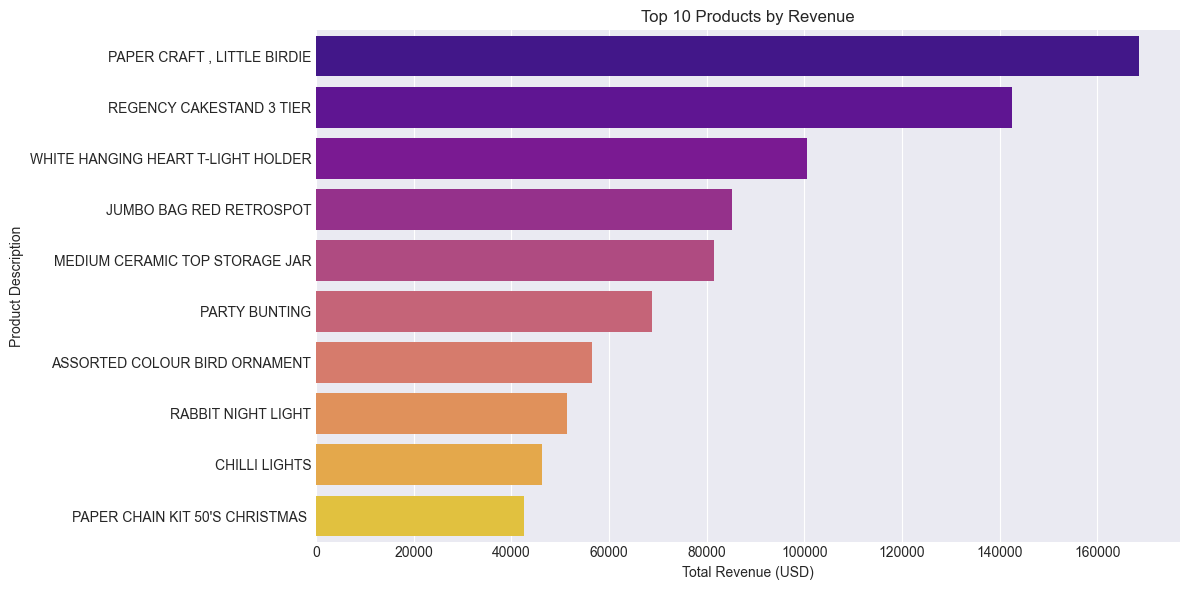

In [29]:
# Calculate top products by revenue
product_revenue = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, hue=product_revenue.index, legend=False, palette='plasma')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Product Description')
plt.title('Top 10 Products by Revenue')
plt.tight_layout()
plt.savefig('../outputs/figures/top_products_revenue.png', dpi=100)
plt.show()

### Top Products Details

In [30]:
print("Top 5 Products by Revenue:")
print("-" * 40)
for i, (product, revenue) in enumerate(product_revenue.head().items(), 1):
    print(f"{i}. {product[:60]}")
    print(f"   Revenue: ${revenue:,.2f}\n")

Top 5 Products by Revenue:
----------------------------------------
1. PAPER CRAFT , LITTLE BIRDIE
   Revenue: $168,469.60

2. REGENCY CAKESTAND 3 TIER
   Revenue: $142,592.95

3. WHITE HANGING HEART T-LIGHT HOLDER
   Revenue: $100,448.15

4. JUMBO BAG RED RETROSPOT
   Revenue: $85,220.78

5. MEDIUM CERAMIC TOP STORAGE JAR
   Revenue: $81,416.73



### Monthly Revenue Trend

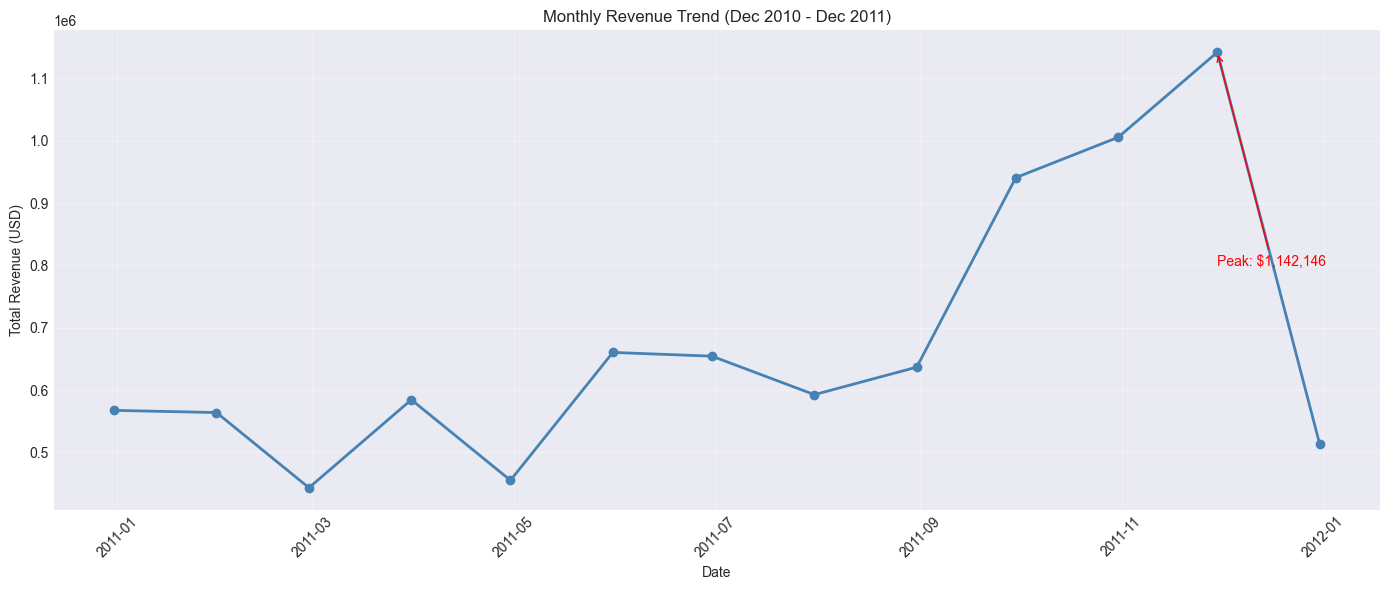

In [31]:
# Use 'ME' for Month End instead of deprecated 'M'
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

# Create visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Total Revenue (USD)')
plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Annotate peak month
max_month = monthly_revenue.idxmax()
max_value = monthly_revenue.max()
plt.annotate(f'Peak: ${max_value:,.0f}', 
             xy=(max_month, max_value), 
             xytext=(max_month, max_value * 0.7),
             arrowprops=dict(arrowstyle='->', color='red'), 
             fontsize=10, color='red')

plt.tight_layout()
plt.savefig('../outputs/figures/monthly_revenue_trend.png', dpi=100)
plt.show()

### Weekly Sales

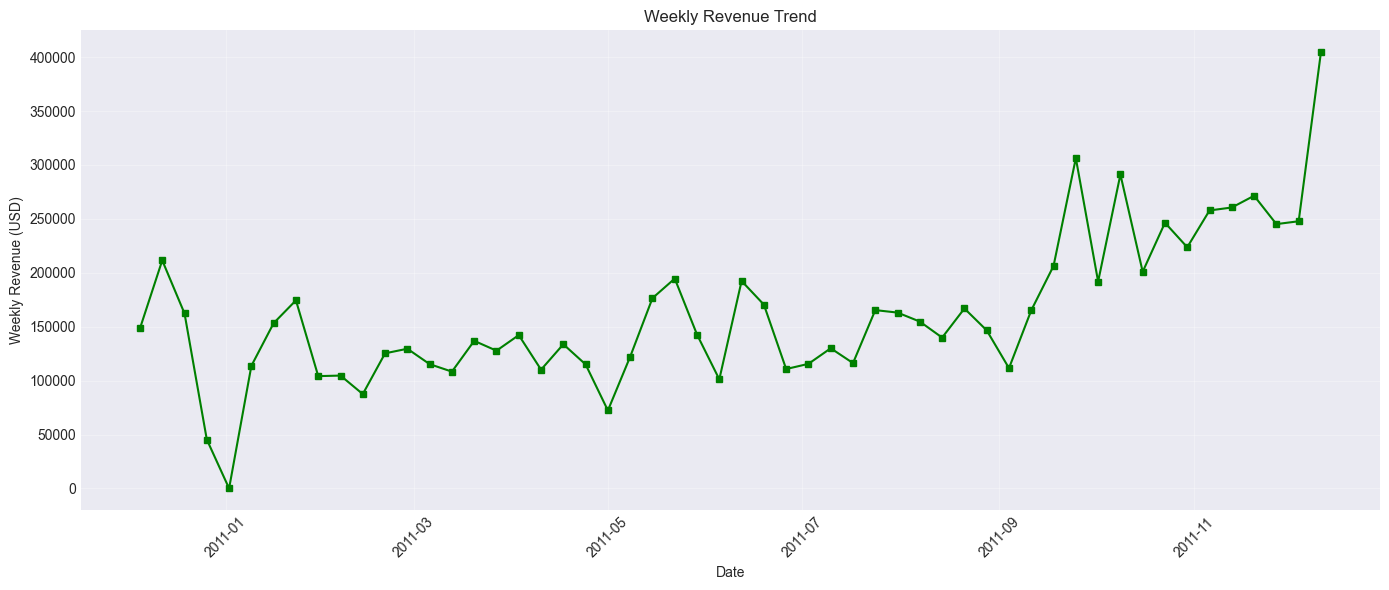

In [32]:
# Weekly aggregation - Use 'W' for weekly (still supported)
weekly_revenue = df_clean.set_index('InvoiceDate').resample('W')['TotalPrice'].sum()

plt.figure(figsize=(14, 6))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker='s', linewidth=1.5, markersize=4, color='green')
plt.xlabel('Date')
plt.ylabel('Weekly Revenue (USD)')
plt.title('Weekly Revenue Trend')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/weekly_revenue_trend.png', dpi=100)
plt.show()

### Monthly Revenue Statistics

In [33]:
# Calculate monthly statistics
print("Monthly Revenue Statistics:")
print("-" * 30)
print(f"Peak revenue month: {max_month.strftime('%B %Y')} (${max_value:,.2f})")

min_month = monthly_revenue.idxmin()
min_value = monthly_revenue.min()
print(f"Lowest revenue month: {min_month.strftime('%B %Y')} (${min_value:,.2f})")

avg_monthly = monthly_revenue.mean()
print(f"Average monthly revenue: ${avg_monthly:,.2f}")

# Calculate month-over-month growth
if len(monthly_revenue) > 1:
    mom_growth = ((monthly_revenue.iloc[-1] - monthly_revenue.iloc[0]) / monthly_revenue.iloc[0]) * 100
    print(f"Overall growth from start to end: {mom_growth:.1f}%")

Monthly Revenue Statistics:
------------------------------
Peak revenue month: November 2011 ($1,142,145.77)
Lowest revenue month: February 2011 ($443,346.02)
Average monthly revenue: $673,928.20
Overall growth from start to end: -9.6%


### Transactions by Hour of Day

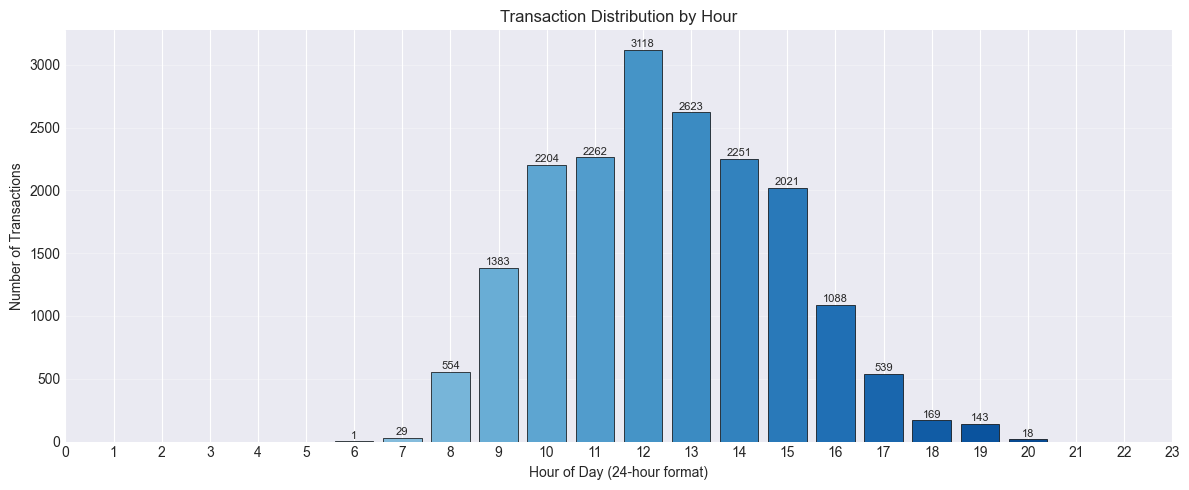

In [34]:
# Aggregate by hour
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique()

# Create visualization with better color options
plt.figure(figsize=(12, 5))

# Option 1: Single color with gradient (recommended)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(hourly_orders)))
bars = plt.bar(hourly_orders.index, hourly_orders.values, color=colors, edgecolor='black', linewidth=0.5)

plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Transactions')
plt.title('Transaction Distribution by Hour')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar, value in zip(bars, hourly_orders.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{value}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/transactions_by_hour.png', dpi=100)
plt.show()

### Peak Hours Analysis

In [35]:
# Find business hours insights
peak_hour = hourly_orders.idxmax()
peak_orders = hourly_orders.max()

print("Hourly Transaction Analysis:")
print("-" * 30)
print(f"Peak transaction hour: {peak_hour}:00 ({peak_orders:,} transactions)")

# Calculate business hours (9 AM - 5 PM)
business_hours = hourly_orders.loc[9:17].sum()
total_transactions = hourly_orders.sum()
print(f"Transactions during business hours (9 AM - 5 PM): {business_hours:,} ({business_hours/total_transactions*100:.1f}%)")

# Calculate evening hours (6 PM - 9 PM)
evening_hours = hourly_orders.loc[18:21].sum()
print(f"Transactions during evening hours (6 PM - 9 PM): {evening_hours:,} ({evening_hours/total_transactions*100:.1f}%)")

Hourly Transaction Analysis:
------------------------------
Peak transaction hour: 12:00 (3,118 transactions)
Transactions during business hours (9 AM - 5 PM): 17,489 (95.0%)
Transactions during evening hours (6 PM - 9 PM): 330 (1.8%)


### Transactions by Day of Week

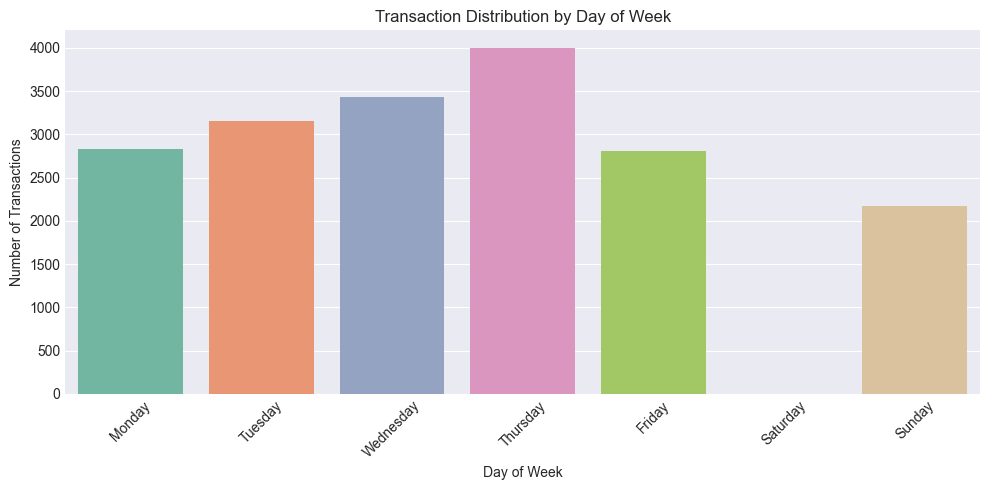

In [36]:
# Aggregate by day of week
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_orders = df_clean.groupby('WeekdayName')['InvoiceNo'].nunique().reindex(weekday_order)

# Create visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=weekly_orders.index, y=weekly_orders.values, hue=weekly_orders.index, legend=False, palette='Set2')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.title('Transaction Distribution by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/transactions_by_weekday.png', dpi=100)
plt.show()

### Weekly Pattern Insights

In [37]:
print("Weekly Transaction Analysis:")
print("-" * 30)
print(f"Best day: {weekly_orders.idxmax()} ({weekly_orders.max():,.0f} transactions)")
print(f"Worst day: {weekly_orders.idxmin()} ({weekly_orders.min():,.0f} transactions)")

# Calculate weekday vs weekend
weekday_avg = weekly_orders.loc[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']].mean()
weekend_avg = weekly_orders.loc[['Saturday', 'Sunday']].mean()
print(f"\nAverage weekday transactions: {weekday_avg:.0f}")
print(f"Average weekend transactions: {weekend_avg:.0f}")
print(f"Weekdays outperform weekends by {((weekday_avg - weekend_avg)/weekend_avg*100):.1f}%")

Weekly Transaction Analysis:
------------------------------
Best day: Thursday (4,003 transactions)
Worst day: Sunday (2,168 transactions)

Average weekday transactions: 3247
Average weekend transactions: 2168
Weekdays outperform weekends by 49.8%


### Top 10 Customers by Spending

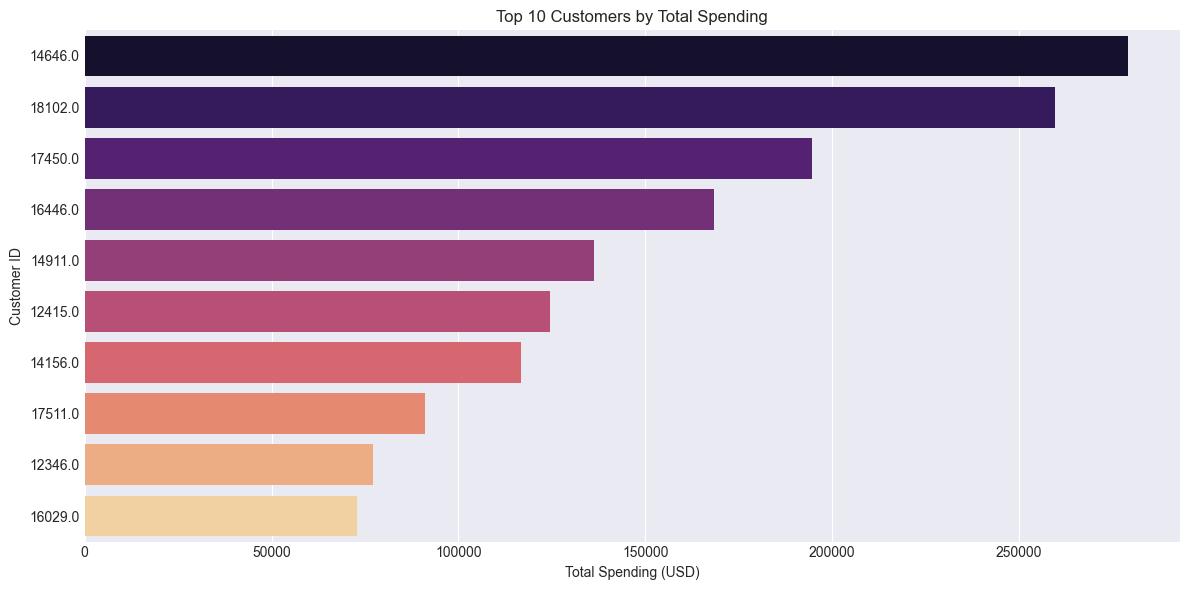

In [38]:
# Calculate top customers
customer_spending = df_clean.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_spending.values, y=customer_spending.index.astype(str), 
            hue=customer_spending.index.astype(str), legend=False, palette='magma')
plt.xlabel('Total Spending (USD)')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Total Spending')
plt.tight_layout()
plt.savefig('../outputs/figures/top_customers.png', dpi=100)
plt.show()

### Customer Spending Analysis

In [39]:
print("Customer Spending Analysis:")
print("-" * 30)
print(f"Top customer spent: ${customer_spending.iloc[0]:,.2f}")
print(f"Top 5 customer average: ${customer_spending.head().mean():,.2f}")
print(f"Top 10 customer average: ${customer_spending.mean():,.2f}")

# Calculate concentration
total_revenue = df_clean['TotalPrice'].sum()
top10_revenue_share = customer_spending.sum() / total_revenue * 100
print(f"\nTop 10 customers contribute: {top10_revenue_share:.1f}% of total revenue")

# Pareto analysis (80/20 rule)
customer_sorted = df_clean.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
cumulative_revenue = customer_sorted.cumsum() / total_revenue
customers_needed_80 = (cumulative_revenue <= 0.8).sum()
print(f"Top {customers_needed_80} customers ({(customers_needed_80/len(customer_sorted)*100):.1f}%) generate 80% of revenue")

Customer Spending Analysis:
------------------------------
Top customer spent: $279,138.02
Top 5 customer average: $207,618.87
Top 10 customer average: $152,051.66

Top 10 customers contribute: 17.4% of total revenue
Top 1135 customers (26.2%) generate 80% of revenue


### Transaction Value Distribution

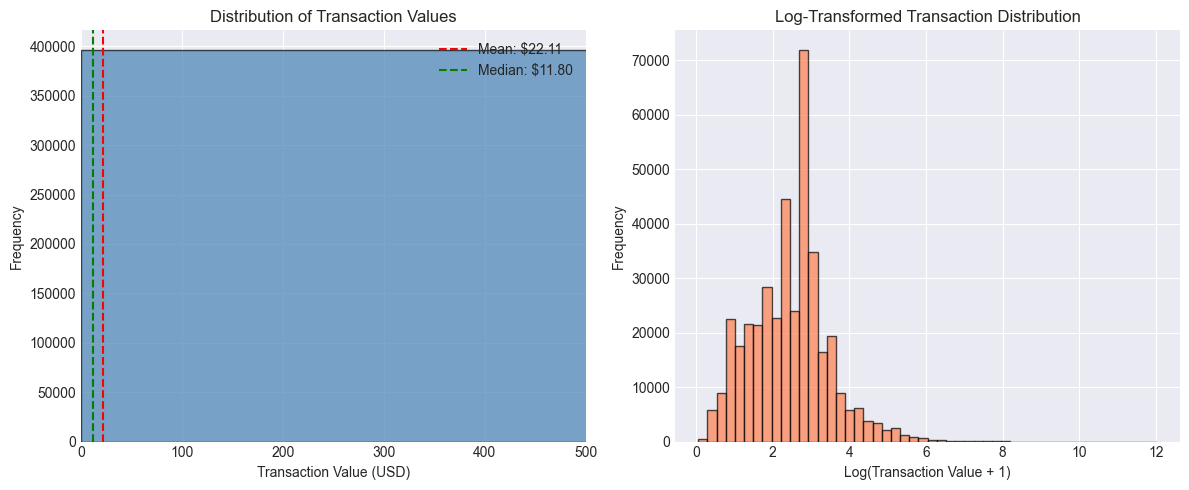

In [40]:
# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw distribution
axes[0].hist(df_clean['TotalPrice'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Transaction Value (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Transaction Values')
axes[0].set_xlim(0, 500)
axes[0].axvline(df_clean['TotalPrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["TotalPrice"].mean():.2f}')
axes[0].axvline(df_clean['TotalPrice'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["TotalPrice"].median():.2f}')
axes[0].legend()

# Log-transformed distribution
axes[1].hist(np.log1p(df_clean['TotalPrice']), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Transaction Value + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Transaction Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/transaction_distribution.png', dpi=100)
plt.show()

### Transaction Statistics

In [41]:
print("Transaction Value Statistics:")
print("-" * 35)
print(df_clean['TotalPrice'].describe())

Transaction Value Statistics:
-----------------------------------
count    396337.000000
mean         22.105094
std         308.899121
min           0.060000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


### Customer Purchase Frequency

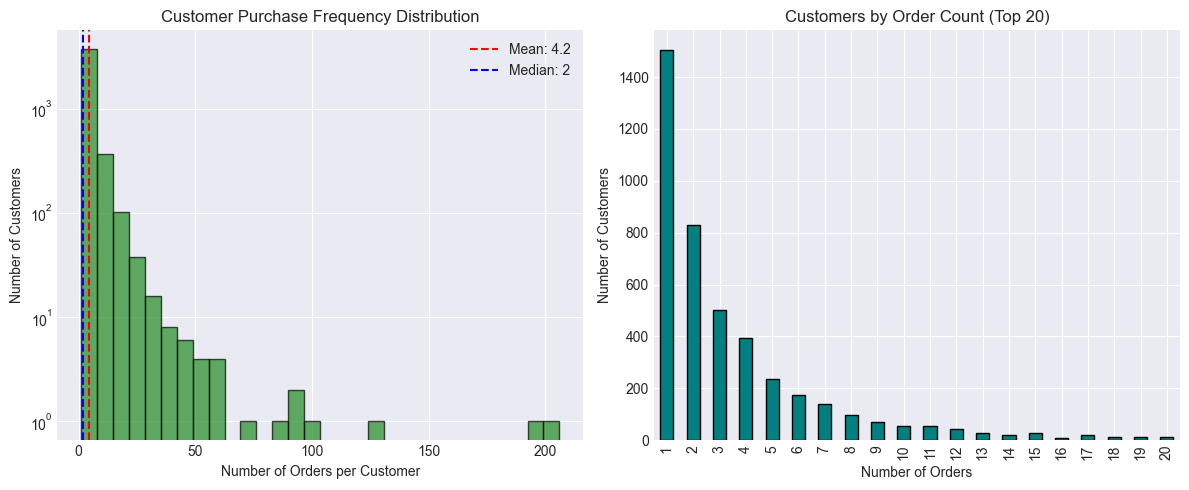

In [42]:
# Calculate customer purchase frequency
customer_frequency = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

# Create histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full distribution with log scale
axes[0].hist(customer_frequency, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Orders per Customer')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Purchase Frequency Distribution')
axes[0].set_yscale('log')
axes[0].axvline(customer_frequency.mean(), color='red', linestyle='--', label=f'Mean: {customer_frequency.mean():.1f}')
axes[0].axvline(customer_frequency.median(), color='blue', linestyle='--', label=f'Median: {customer_frequency.median():.0f}')
axes[0].legend()

# Top frequencies
customer_frequency.value_counts().sort_index().head(20).plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customers by Order Count (Top 20)')

plt.tight_layout()
plt.savefig('../outputs/figures/customer_frequency.png', dpi=100)
plt.show()

### Customer Frequency Insights

In [43]:
print("Customer Purchase Frequency Analysis:")
print("-" * 35)
print(f"Average orders per customer: {customer_frequency.mean():.2f}")
print(f"Median orders per customer: {customer_frequency.median():.0f}")

one_time = (customer_frequency == 1).sum()
print(f"One-time customers: {one_time:,} ({one_time/len(customer_frequency)*100:.1f}%)")

repeat_customers = (customer_frequency >= 2).sum()
print(f"Repeat customers (2+ orders): {repeat_customers:,} ({repeat_customers/len(customer_frequency)*100:.1f}%)")

frequent_customers = (customer_frequency >= 10).sum()
print(f"Frequent customers (10+ orders): {frequent_customers:,}")

Customer Purchase Frequency Analysis:
-----------------------------------
Average orders per customer: 4.25
Median orders per customer: 2
One-time customers: 1,505 (34.7%)
Repeat customers (2+ orders): 2,829 (65.3%)
Frequent customers (10+ orders): 386


### Order Value Distribution

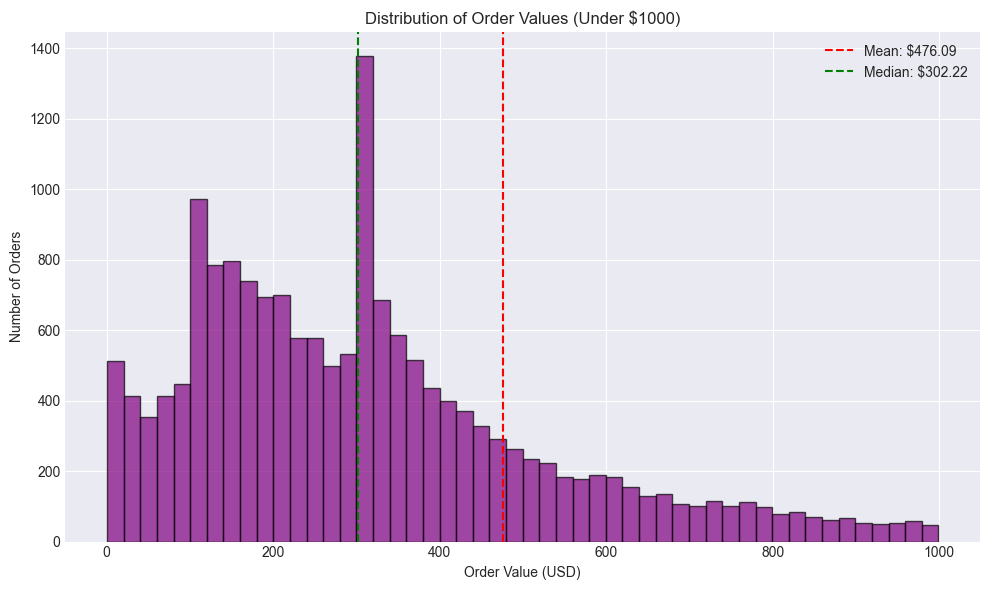

In [44]:
# Calculate order values
order_value = df_clean.groupby('InvoiceNo')['TotalPrice'].sum()

# Create histogram (excluding extreme outliers)
plt.figure(figsize=(10, 6))
plt.hist(order_value[order_value < 1000], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Values (Under $1000)')
plt.axvline(order_value.mean(), color='red', linestyle='--', label=f'Mean: ${order_value.mean():.2f}')
plt.axvline(order_value.median(), color='green', linestyle='--', label=f'Median: ${order_value.median():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/order_value_distribution.png', dpi=100)
plt.show()

### Order Value Statistics

In [45]:
print("Order Value Statistics:")
print("-" * 30)
print(f"Average order value: ${order_value.mean():.2f}")
print(f"Median order value: ${order_value.median():.2f}")
print(f"Minimum order value: ${order_value.min():.2f}")
print(f"Maximum order value: ${order_value.max():.2f}")

# Calculate order value segments
small_orders = (order_value < 50).sum()
medium_orders = ((order_value >= 50) & (order_value < 200)).sum()
large_orders = ((order_value >= 200) & (order_value < 500)).sum()
xlarge_orders = (order_value >= 500).sum()

print(f"\nOrder Value Segmentation:")
print(f"  Small orders (<$50): {small_orders:,} ({small_orders/len(order_value)*100:.1f}%)")
print(f"  Medium orders ($50-$200): {medium_orders:,} ({medium_orders/len(order_value)*100:.1f}%)")
print(f"  Large orders ($200-$500): {large_orders:,} ({large_orders/len(order_value)*100:.1f}%)")
print(f"  Extra large orders ($500+): {xlarge_orders:,} ({xlarge_orders/len(order_value)*100:.1f}%)")

Order Value Statistics:
------------------------------
Average order value: $476.09
Median order value: $302.22
Minimum order value: $0.38
Maximum order value: $168469.60

Order Value Segmentation:
  Small orders (<$50): 1,084 (5.9%)
  Medium orders ($50-$200): 5,038 (27.4%)
  Large orders ($200-$500): 8,150 (44.3%)
  Extra large orders ($500+): 4,130 (22.4%)


### Save Summary Statistics to CSV

In [46]:
# Create summary dataframe
summary_stats = {
    'Metric': ['Total Transactions', 'Unique Customers', 'Unique Products', 'Unique Countries', 
               'Total Revenue', 'Average Transaction Value', 'Median Transaction Value',
               'Average Orders per Customer', 'One-time Customers', 'UK Revenue Share',
               'Peak Month', 'Peak Transaction Hour', 'Best Day for Transactions'],
    'Value': [len(df_clean), df_clean['CustomerID'].nunique(), df_clean['StockCode'].nunique(),
              df_clean['Country'].nunique(), f"${df_clean['TotalPrice'].sum():,.2f}",
              f"${df_clean['TotalPrice'].mean():.2f}", f"${df_clean['TotalPrice'].median():.2f}",
              f"{customer_frequency.mean():.2f}", f"{(customer_frequency == 1).sum():,}",
              f"{(uk_revenue/df_clean['TotalPrice'].sum()*100):.1f}%",
              f"{max_month.strftime('%B %Y')}", f"{peak_hour}:00", weekly_orders.idxmax()]
}

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('../outputs/tables/summary_statistics.csv', index=False)

print("Summary statistics saved to ../outputs/tables/summary_statistics.csv")

Summary statistics saved to ../outputs/tables/summary_statistics.csv


### Save Key DataFrames for Reference

In [47]:
# Save top lists for reference
country_revenue.to_csv('../outputs/tables/top_countries.csv', header=['Revenue'])
product_revenue.to_csv('../outputs/tables/top_products.csv', header=['Revenue'])
customer_spending.to_csv('../outputs/tables/top_customers.csv', header=['Total_Spending'])

# Save additional analysis
order_value.to_csv('../outputs/tables/order_values.csv', header=['Order_Value'])
customer_frequency.to_csv('../outputs/tables/customer_frequency.csv', header=['Order_Count'])

print("All data saved to outputs/tables/")
print("  - summary_statistics.csv")
print("  - top_countries.csv")
print("  - top_products.csv")
print("  - top_customers.csv")
print("  - order_values.csv")
print("  - customer_frequency.csv")

All data saved to outputs/tables/
  - summary_statistics.csv
  - top_countries.csv
  - top_products.csv
  - top_customers.csv
  - order_values.csv
  - customer_frequency.csv


### Final Notes

In [48]:
print("\n" + "=" * 50)
print("EXPLORATORY DATA ANALYSIS COMPLETE")
print("=" * 50)
print("\nKey findings from this analysis:")
print("1. UK dominates revenue, but international presence exists")
print("2. Peak transaction hours are during business hours")
print("3. Thursday/Friday are best days for transactions")
print("4. High customer concentration - top customers drive significant revenue")
print("5. Transaction values are right-skewed, log transformation needed for modeling")


EXPLORATORY DATA ANALYSIS COMPLETE

Key findings from this analysis:
1. UK dominates revenue, but international presence exists
2. Peak transaction hours are during business hours
3. Thursday/Friday are best days for transactions
4. High customer concentration - top customers drive significant revenue
5. Transaction values are right-skewed, log transformation needed for modeling
